In [1]:
!pip install ultralytics roboflow

  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 29.3 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 10.5 MB/s  0:00:00 eta 0:00:01
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
  Attempting uninstall: idna╺━━━━━━━━━━━━━━━━━━━━━━━━ 3/8 [opencv-python-headless]
    Found existing installation: idna 3.11━━━━━━━━━━━━━━━━━━━━ 3/8 [opencv-python-headless]
    Uninstalling idna-3.11:m╺━━━━━━━━━━━━━━━━━━━━━━━━ 3/8 [opencv-python-headless]
      Successfully uninstalled idna-3.11━━━━━━━━━━━━━━━━━━━━━━ 3/8 [opencv-python-headless]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [roboflow]7/8 [roboflow]-headless]


In [2]:


from roboflow import Roboflow
rf = Roboflow(api_key="21ULs2ad9pwRjPzUlLRl")
project = rf.workspace("basirs-workspace").project("lados-l88zu")
version = project.version(1)
dataset = version.download("coco-segmentation")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to LADOS-1 in coco-segmentation:: 100%|█| 3392/3392 [00:00<00:00, 8398.29it/s


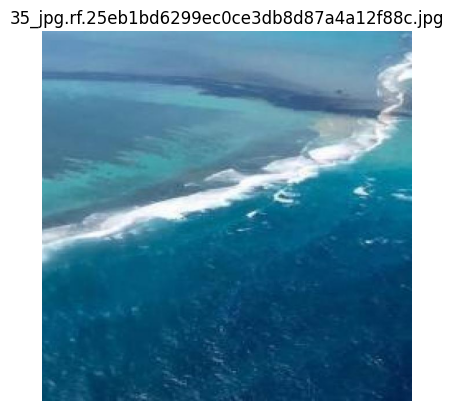

In [3]:
import json
import cv2
import matplotlib.pyplot as plt

with open("LADOS-1/train/_annotations.coco.json") as f:
    coco = json.load(f)

image_info = coco["images"][0]   # first image
image_path = "LADOS-1/train/" + image_info["file_name"]

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(image_info["file_name"])
plt.axis("off")
plt.show()

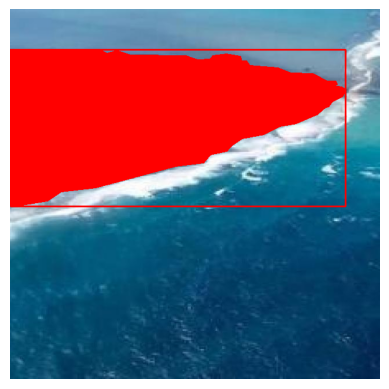

In [4]:
import numpy as np

#bonding box
for ann in coco["annotations"]:
    if ann["image_id"] == image_info["id"]:
        x, y, w, h = ann["bbox"]
        cv2.rectangle(img, (int(x), int(y)), (int(x+w), int(y+h)), (255,0,0), 2)

#segment
for ann in coco["annotations"]:
    if ann["image_id"] == image_info["id"]:

        for seg in ann["segmentation"]:
            polygon = np.array(seg).reshape((-1, 2)).astype(int)

            # draw polygon
            cv2.polylines(img, [polygon], True, (255,0,0), 2)

            # optional: fill the polygon
            cv2.fillPoly(img, [polygon], (255,0,0))
plt.imshow(img)
plt.axis("off")
plt.show()

In [6]:
import os
import json
from pathlib import Path
from PIL import Image
from tqdm import tqdm

def convert(coco_path, images_root, out_img_dir, out_lbl_dir):
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    with open(coco_path, "r") as f:
        coco = json.load(f)

    print("Images:", len(coco["images"]))
    print("Annotations:", len(coco["annotations"]))

    cat_map = {c["id"]: i for i, c in enumerate(coco["categories"])}

    ann_map = {}
    for ann in coco["annotations"]:
        ann_map.setdefault(ann["image_id"], []).append(ann)

    missing = 0
    used = 0

    for img in tqdm(coco["images"]):
        file_name = img["file_name"]

        # FIX: try both raw and basename paths
        img_path = os.path.join(images_root, file_name)

        if not os.path.exists(img_path):
            img_path = os.path.join(images_root, os.path.basename(file_name))

        if not os.path.exists(img_path):
            missing += 1
            continue

        used += 1

        out_img_path = os.path.join(out_img_dir, Path(file_name).name)
        Image.open(img_path).save(out_img_path)

        w, h = img["width"], img["height"]

        labels = []

        for ann in ann_map.get(img["id"], []):
            x, y, bw, bh = ann["bbox"]

            x_center = (x + bw / 2) / w
            y_center = (y + bh / 2) / h
            bw /= w
            bh /= h

            cls = cat_map[ann["category_id"]]

            labels.append(f"{cls} {x_center} {y_center} {bw} {bh}")

        label_path = os.path.join(out_lbl_dir, Path(file_name).stem + ".txt")

        with open(label_path, "w") as f:
            f.write("\n".join(labels))

    print("\nDONE")
    print("Used images:", used)
    print("Missing images:", missing)


def run_split(split):
    base = f"LADOS-1/{split}"

    convert(
        coco_path=f"{base}/_annotations.coco.json",
        images_root=base,
        out_img_dir=f"yolo_dataset/images/{split}",
        out_lbl_dir=f"yolo_dataset/labels/{split}",
    )

for s in ["train", "valid", "test"]:
    run_split(s)

Images: 2370
Annotations: 4526


100%|██████████████████████████████████████████████████████████████████| 2370/2370 [00:03<00:00, 684.32it/s]



DONE
Used images: 2370
Missing images: 0
Images: 675
Annotations: 1323


100%|████████████████████████████████████████████████████████████████████| 675/675 [00:00<00:00, 686.05it/s]



DONE
Used images: 675
Missing images: 0
Images: 343
Annotations: 613


100%|████████████████████████████████████████████████████████████████████| 343/343 [00:00<00:00, 671.09it/s]


DONE
Used images: 343
Missing images: 0


In [10]:
import os

YAML = """path: yolo_dataset

train: images/train
val: images/valid
test: images/test

names:
  0: background
  1: emulsion
  2: oil
  3: oil-platform
  4: sheen
  5: ship
  """

with open("yolo_dataset/data.yaml", "w") as f:
    f.write(YAML)

In [12]:
class_map = {
    0: "background",
    1: "emulsion",
    2: "oil",
    3: "oil-platform",
    4: "sheen",
    5: "ship"
}

In [ ]:
!yolo detect train \
  model=yolo26n.pt \
  data=yolo_dataset/data.yaml \
  epochs=100 \
  imgsz=640 \
  batch=16

Ultralytics 8.4.37 🚀 Python-3.11.9 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

!unzip /content/yolov8_run_results2

In [13]:
import pandas as pd

results_df = pd.read_csv('../.pyenv/runs/detect/train2/results.csv')
results_df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,23.5070,0.99503,2.97659,1.47271,0.53085,0.29738,0.26757,0.15451,1.27270,2.33089,1.65416,0.000331,0.000331,0.000331
1,2,35.7341,1.01108,2.10727,1.50041,0.51430,0.34989,0.30256,0.17098,1.37580,2.33513,1.75410,0.000658,0.000658,0.000658
2,3,47.0060,0.99687,1.92544,1.50616,0.28980,0.31417,0.24603,0.12291,1.61349,2.66797,1.80595,0.000978,0.000978,0.000978
3,4,58.2830,0.99345,1.81486,1.49568,0.63520,0.32592,0.33827,0.19298,1.39575,2.03968,1.82647,0.000970,0.000970,0.000970
4,5,69.5738,0.96505,1.70538,1.47977,0.68607,0.31379,0.35571,0.19795,1.40073,2.04548,1.66277,0.000960,0.000960,0.000960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,1091.3300,0.57281,0.61053,1.18462,0.82421,0.68254,0.74487,0.51900,0.97065,1.01958,1.25306,0.000060,0.000060,0.000060
96,97,1102.3300,0.57558,0.59272,1.19369,0.80028,0.69433,0.74410,0.51714,0.97087,1.00986,1.24766,0.000050,0.000050,0.000050
97,98,1113.5600,0.56895,0.62180,1.18223,0.78835,0.69271,0.74131,0.51269,0.97898,1.01846,1.26362,0.000040,0.000040,0.000040
98,99,1124.9100,0.55329,0.57234,1.16833,0.84991,0.64203,0.74621,0.51390,0.97608,1.01294,1.25784,0.000030,0.000030,0.000030


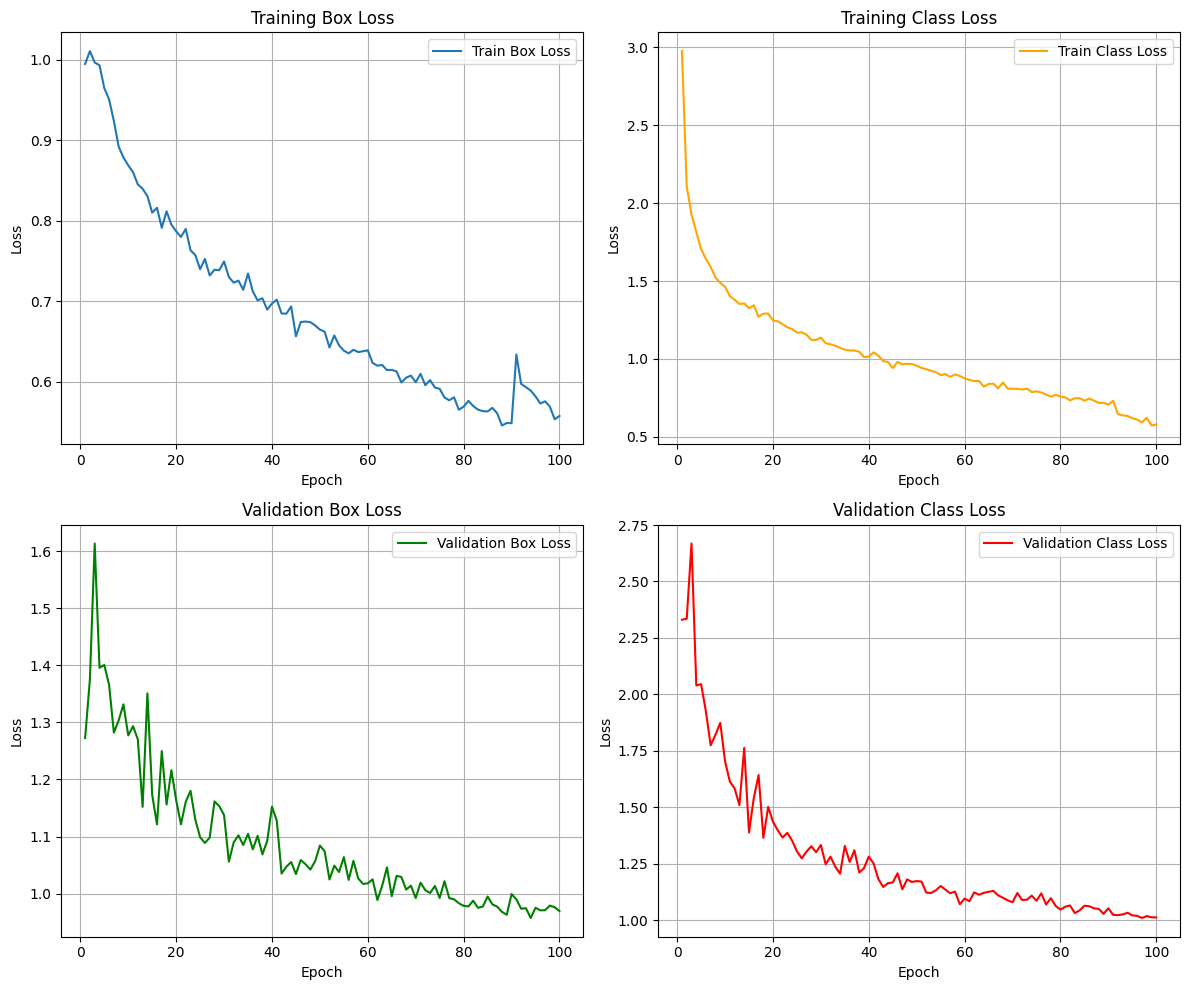

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot train/box_loss
axes[0, 0].plot(results_df['epoch'], results_df['train/box_loss'], label='Train Box Loss')
axes[0, 0].set_title('Training Box Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot train/cls_loss
axes[0, 1].plot(results_df['epoch'], results_df['train/cls_loss'], label='Train Class Loss', color='orange')
axes[0, 1].set_title('Training Class Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot val/box_loss
axes[1, 0].plot(results_df['epoch'], results_df['val/box_loss'], label='Validation Box Loss', color='green')
axes[1, 0].set_title('Validation Box Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot val/cls_loss
axes[1, 1].plot(results_df['epoch'], results_df['val/cls_loss'], label='Validation Class Loss', color='red')
axes[1, 1].set_title('Validation Class Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


image 1/1 /home/labpc/OilSpill/yolo_dataset/images/test/5fd2d380-7151-4754-98dc-9d1097556ad2_jpg.rf.3085185c4f10201ed7aa6f033957b62b.jpg: 640x640 1 emulsion, 7.5ms
Speed: 1.2ms preprocess, 7.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


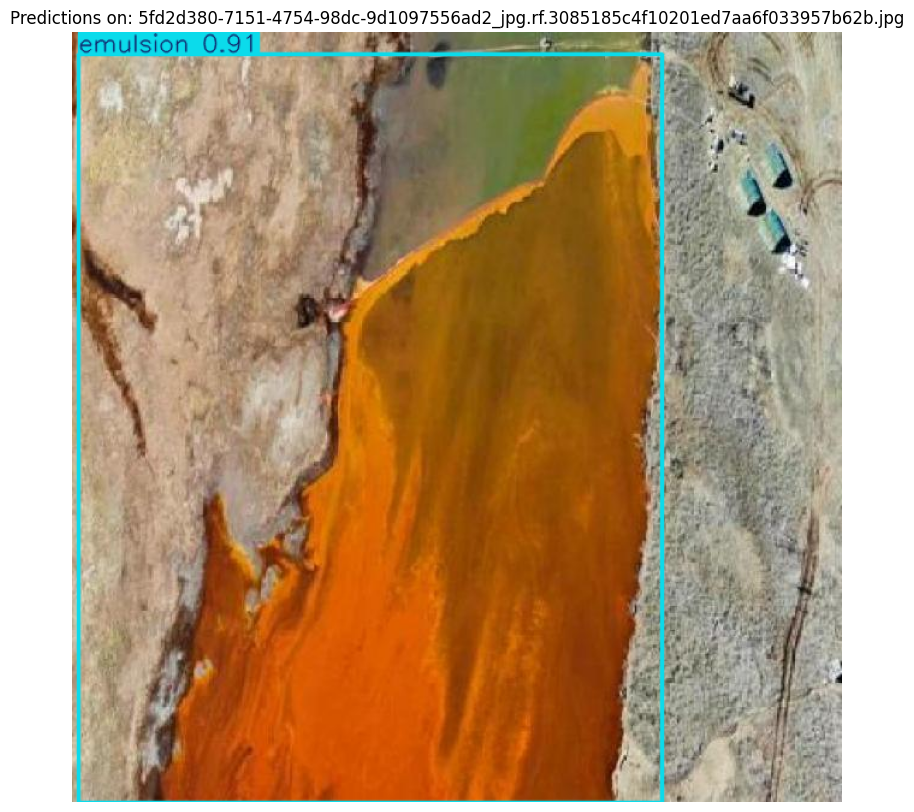

In [21]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

# Load the trained model
model = YOLO('../.pyenv/runs/detect/train2/weights/best.pt')

# Get an example image from the test set
test_image_dir = 'yolo_dataset/images/test'

# List all files in the directory and pick the first image
image_files = [f for f in os.listdir(test_image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
index = 2
if image_files:
    example_image_path = os.path.join(test_image_dir, image_files[index])

    # Run inference on the example image
    results = model.predict(source=example_image_path, conf=0.25, iou=0.7)

    # Display the results
    # The 'results' object contains annotated images. We'll show the first one.
    for r in results:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB) # convert to RGB for matplotlib
        plt.figure(figsize=(10, 10))
        plt.imshow(im_rgb)
        plt.axis('off')
        plt.title(f"Predictions on: {image_files[index]}")
        plt.show()
else:
    print(f"No image files found in {test_image_dir}")

--- Using the trained DETECTION model ---


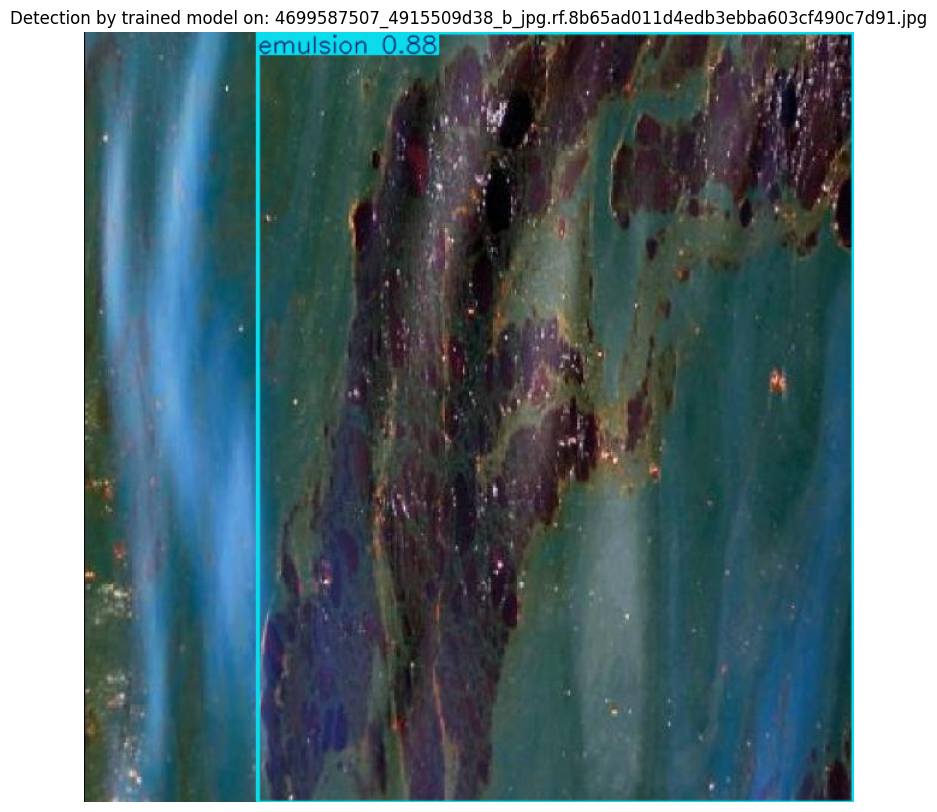


--- Performing SEGMENTATION using a pre-trained YOLOv8-seg model ---
No segmentation masks found for the image using the segmentation model.


In [18]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

# --- Using the user's trained DETECTION model ---
print("--- Using the trained DETECTION model ---")
# Load the user's trained model (which is a detection model)
detection_model = YOLO('../.pyenv/runs/detect/train2/weights/best.pt')

# Get an example image from the test set
test_image_dir = 'yolo_dataset/images/test'
image_files = [f for f in os.listdir(test_image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
index = 3 # Using the same index as the previous execution

if image_files:
    example_image_path = os.path.join(test_image_dir, image_files[index])

    # Run inference with the detection model
    detection_results = detection_model.predict(source=example_image_path, conf=0.25, iou=0.7, verbose=False)

    # Display the detection results (bounding boxes)
    for r in detection_results:
        im_array_det = r.plot()  # plots bounding boxes
        im_rgb_det = cv2.cvtColor(im_array_det, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        plt.imshow(im_rgb_det)
        plt.axis('off')
        plt.title(f"Detection by trained model on: {image_files[index]}")
        plt.show()

    # --- Performing SEGMENTATION using a pre-trained segmentation model ---
    print("\n--- Performing SEGMENTATION using a pre-trained YOLOv8-seg model ---")
    # Load a pre-trained YOLOv8 segmentation model
    segmentation_model = YOLO('yolov8n-seg.pt') # This model will be downloaded if not present

    # Run inference with the segmentation model on the same image
    segmentation_results = segmentation_model.predict(source=example_image_path, conf=0.25, iou=0.7, verbose=False)

    # Display the segmentation results (masks and bounding boxes)
    for r_seg in segmentation_results:
        # Check if masks are present in the results
        if r_seg.masks is not None:
            im_array_seg = r_seg.plot(boxes=True, masks=True) # plots masks and bounding boxes
            im_rgb_seg = cv2.cvtColor(im_array_seg, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(10, 10))
            plt.imshow(im_rgb_seg)
            plt.axis('off')
            plt.title(f"Segmentation by YOLOv8n-seg model on: {image_files[index]}")
            plt.show()
        else:
            print("No segmentation masks found for the image using the segmentation model.")
else:
    print(f"No image files found in {test_image_dir}")